C:\Users\Lenovo\AppData\Local\Temp\ipykernel_22264\2231298651.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


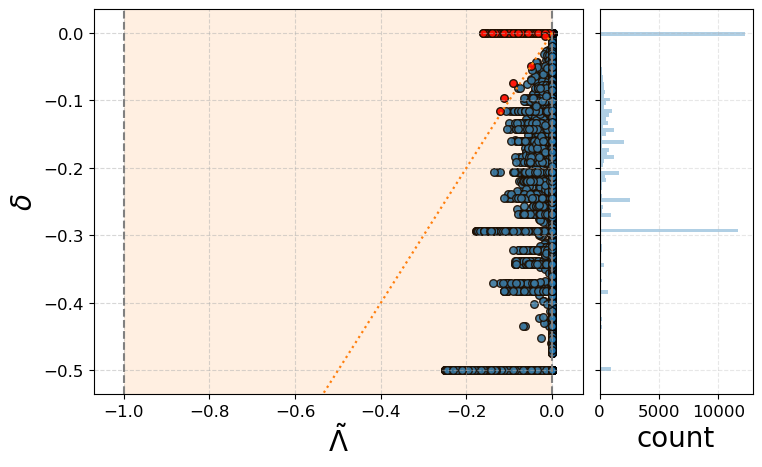

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_22264\2231298651.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


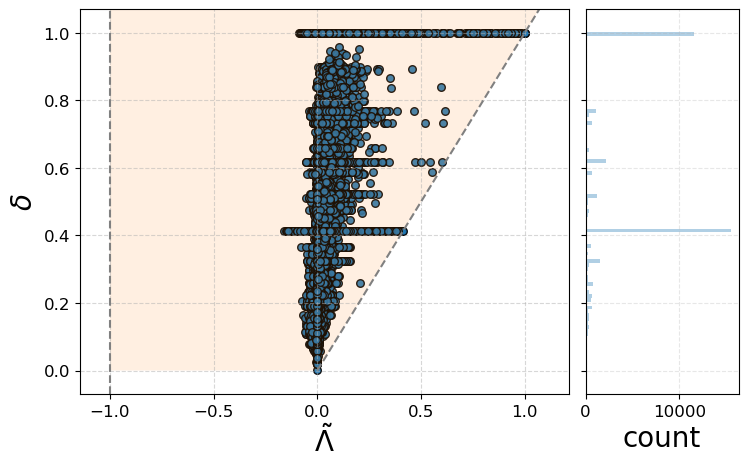

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =======================
# 你只需要改这里：base_folder
# growth_factors.dat / kinetics.dat / stoichiometries_formatted.txt 都在这个目录下
# =======================
BASE_FOLDER = r"Data\New_Bound_Randomize_Topo_and_Kinetics_order2_accuracy_1e-4\results_order2_100Kpoints"


# -----------------------
# Plot settings
# -----------------------
tick_fs  = 12
label_fs = 20

bins_hist = 100
use_hist  = True
use_kde   = False

tol_alpha = 1e-4


def pad_range(vmin, vmax, frac=0.07):
    span = vmax - vmin
    if span < 1e-12:
        span = 1.0
    p = frac * span
    return vmin - p, vmax + p


def kde_counts_1d(samples, y_grid, bin_width, bw=None):
    samples = np.asarray(samples, dtype=float)
    n = samples.size
    if n < 2:
        return np.zeros_like(y_grid)
    std = samples.std(ddof=1)
    if bw is None:
        bw = 1.06 * std * (n ** (-1/5)) if std > 1e-12 else 1.0
    diff = (y_grid[:, None] - samples[None, :]) / bw
    pdf = np.exp(-0.5 * diff**2).sum(axis=1) / (n * bw * np.sqrt(2*np.pi))
    return pdf * n * bin_width


def get_col(df, candidates, required=False):
    """尝试多个可能的列名，找到就返回 numpy array。"""
    for c in candidates:
        if c in df.columns:
            return df[c].to_numpy()
    if required:
        raise KeyError(f"缺少必要列：{candidates}\n当前文件列名：{list(df.columns)}")
    return None


def plot_with_right_distribution(x, y, mode, out_dir, pdf_name, viol_mask=None, ref_point=None):
    """
    mode = "lt"  : alpha<1  bound shading: -1 <= x <= 0
    mode = "ge"  : alpha>=1 shading: -1 <= x <= y for y>=0
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    fig = plt.figure(figsize=(8.5, 5))
    gs = fig.add_gridspec(1, 2, width_ratios=[3.2, 1.0], wspace=0.05)
    ax  = fig.add_subplot(gs[0, 0])
    axh = fig.add_subplot(gs[0, 1], sharey=ax)

    # ---- scatter ----
    if x.size:
        if viol_mask is None:
            ax.scatter(x, y, s=30, edgecolors='k', alpha=0.9)
        else:
            viol_mask = np.asarray(viol_mask, dtype=bool)
            ax.scatter(x[~viol_mask], y[~viol_mask], s=30, edgecolors='k', alpha=0.9)
            if np.any(viol_mask):
                ax.scatter(x[viol_mask], y[viol_mask], s=30, color='red', edgecolors='k', alpha=0.95)

    # ---- y limits ----
    if y.size:
        ymin, ymax = pad_range(y.min(), y.max())
    else:
        ymin, ymax = (-1.0, 1.0)
    ax.set_ylim(ymin, ymax)

    # ---- shading + reference lines ----
    if mode == "lt":
        yy = np.linspace(ymin, ymax, 400)
        ax.fill_betweenx(yy, -1.0, 0.0, alpha=0.12)
        ax.axvline(-1.0, ls='--', color='gray')
        ax.axvline(0.0,  ls='--', color='gray')

        d_end = max(-1.0, ymin)
        if d_end < 0.0:
            ax.plot([0.0, d_end], [0.0, d_end], ls=':', lw=1.6, color='tab:orange')

        xmin = min(-1.0, x.min()) if x.size else -1.0
        xmax = max(0.0,  x.max()) if x.size else 0.0
        ax.set_xlim(*pad_range(xmin, xmax))

    elif mode == "ge":
        y_lo = max(0.0, ymin)
        if y_lo < ymax:
            yy = np.linspace(y_lo, ymax, 400)
            ax.fill_betweenx(yy, -1.0, yy, alpha=0.12)

        ax.axvline(-1.0, ls='--', color='gray')
        if ymax > 0.0:
            ax.plot([0.0, ymax], [0.0, ymax], ls='--', color='gray')

        xmax = max(x.max(), ymax) if x.size else max(1.0, ymax)
        ax.set_xlim(*pad_range(-1.0, xmax))

    ax.set_xlabel(r'$\tilde{\Lambda}$', fontsize=label_fs)
    ax.set_ylabel(r'$\delta$', fontsize=label_fs)
    ax.grid(linestyle="--", alpha=0.5)
    ax.tick_params(axis='both', which='major', labelsize=tick_fs)

    # ---- right histogram ----
    axh.grid(linestyle="--", alpha=0.3)
    axh.tick_params(axis='both', which='major', labelsize=tick_fs)
    plt.setp(axh.get_yticklabels(), visible=False)

    if y.size:
        y_range = ymax - ymin
        bin_width = y_range / bins_hist

        if use_hist:
            axh.hist(
                y, bins=bins_hist, range=(ymin, ymax),
                orientation="horizontal", density=False,
                alpha=0.35, edgecolor="none"
            )

        if use_kde:
            yy = np.linspace(ymin, ymax, 400)
            kde_x = kde_counts_1d(y, yy, bin_width=bin_width, bw=None)
            axh.plot(kde_x, yy, lw=1.5)

    axh.set_xlabel("count", fontsize=label_fs)

    # ---- optional reference point (保持接口一致) ----
    if ref_point is not None:
        y_ref, x_ref = ref_point[0], ref_point[1]
        if (mode == "lt" and y_ref < -tol_alpha) or (mode == "ge" and y_ref >= -tol_alpha):
            ax.scatter([x_ref], [y_ref], s=60, color='red', edgecolors='k', zorder=5)

    fig.tight_layout()
    fig.savefig(os.path.join(out_dir, pdf_name), bbox_inches="tight")
    plt.show()


def main():
    base_folder = BASE_FOLDER
    data_path = os.path.join(base_folder, "growth_factors.dat")
    if not os.path.isfile(data_path):
        raise FileNotFoundError(f"找不到 {data_path}，请检查 BASE_FOLDER 是否指向 save_all_results 的 base_folder。")

    # 输出目录：我这里默认放到 base_folder 下的 figures/
    out_dir = os.path.join(base_folder, "figures")
    os.makedirs(out_dir, exist_ok=True)

    # 你保存时是 sep='\t'
    df = pd.read_csv(data_path, sep="\t")

    # ---- 从文件读出需要的列 ----
    lam_tilde = get_col(df, ["lambda_tilde", "lam_tilde", "Lambda_tilde", "tildeLambda"], required=True)

    # delta 优先读文件；如果文件没有 delta 但有 alpha，就用 delta = alpha - 1
    delta = get_col(df, ["delta", "Delta"], required=False)
    alpha = get_col(df, ["alpha", "Alpha"], required=False)
    if delta is None:
        if alpha is None:
            raise KeyError("growth_factors.dat 里必须至少有一列：delta 或 alpha（用于 delta=alpha-1）。")
        delta = np.asarray(alpha, dtype=float) - 1.0
    else:
        delta = np.asarray(delta, dtype=float)

    # violation（如果你 growth_list 里存过 violation，就能读到；没有就不画红点）
    is_lt = delta < -tol_alpha
    is_ge = delta >  tol_alpha          # strictly >0 region
    is_eq = ~(is_lt | is_ge)            # |delta| <= tol_alpha  (alpha≈1)
    
    viol = np.zeros_like(delta, dtype=bool)
    viol[is_lt] = delta[is_lt] > lam_tilde[is_lt]      # violates delta <= lambda_tilde
    viol[is_ge] = delta[is_ge] < lam_tilde[is_ge]      # violates lambda_tilde <= delta
    viol[is_eq] = lam_tilde[is_eq] < 0.0               # your alpha=1 rule

    # ---- 分组：alpha<1 <=> delta<0（按你原逻辑） ----
    mask_lt = delta <= tol_alpha
    mask_ge = delta > tol_alpha

    # alpha≈1 的带状区域强制 delta=0（和你原代码一致）
    delta_plot = delta.copy()
    delta_plot[np.abs(delta_plot) < tol_alpha] = 0.0

    vA = viol[mask_lt] if viol is not None else None
    vB = viol[mask_ge] if viol is not None else None

    # ---- FIG A ----
    plot_with_right_distribution(
        x=lam_tilde[mask_lt],
        y=delta_plot[mask_lt],
        mode="lt",
        out_dir=out_dir,
        pdf_name="bound_alpha_lt1_with_delta_dist.pdf",
        viol_mask=vA,
        ref_point=None
    )

    # ---- FIG B ----
    plot_with_right_distribution(
        x=lam_tilde[mask_ge],
        y=delta_plot[mask_ge],
        mode="ge",
        out_dir=out_dir,
        pdf_name="bound_alpha_ge1_with_delta_dist.pdf",
        viol_mask=vB,
        ref_point=None
    )


if __name__ == "__main__":
    main()